# Data Cleaning + Data Merging

In [1]:
import pandas as pd
import json
import os
import numpy as np


SLEEP_STATE_MAP = {2: 'deep', 3: 'light', 4: 'REM', 5: 'Wake up'}
HR_MIN, HR_MAX = 35, 180 

def safe_json_load(x):
    try:
        return json.loads(x) if isinstance(x, str) else x
    except:
        return {}

# load manual logs with flexible column handling and cleaning
def load_manual_logs(manual_log_file):
    df_manual = pd.read_csv(manual_log_file)
    rename_map = {}
    for col in df_manual.columns:
        col_stripped = col.strip()
        if col_stripped.startswith('night_id'): rename_map[col] = 'night_id'
        elif col_stripped.startswith('activity'): rename_map[col] = 'activity_type'
        elif col_stripped.startswith('intervention_start_utc'): rename_map[col] = 'intervention_start_utc'
        elif col_stripped.startswith('device_cessation_utc'): rename_map[col] = 'device_cessation_utc'
        elif col_stripped.startswith('is_outlier'): rename_map[col] = 'is_outlier'
        elif col_stripped.startswith('vitality_score'): rename_map[col] = 'vitality_score'
        elif col_stripped.startswith('outlier_reason'): rename_map[col] = 'outlier_reason'
        elif col_stripped.startswith('user_id'): rename_map[col] = 'user_id'

    df_manual = df_manual.rename(columns=rename_map)
    df_manual = df_manual[pd.to_numeric(df_manual['user_id'], errors='coerce').notna()].copy()
    df_manual['user_id'] = df_manual['user_id'].astype(str).str.strip()
    df_manual['night_id_dt'] = pd.to_datetime(df_manual['night_id']).dt.date
    df_manual['activity_type'] = pd.to_numeric(df_manual['activity_type'], errors='coerce')
    df_manual['is_outlier'] = pd.to_numeric(df_manual['is_outlier'], errors='coerce').fillna(0).astype(int)
    df_manual['analog_activity'] = (df_manual['activity_type'] == 1).astype(int)
    df_manual['digital_activity'] = (df_manual['activity_type'] == 0).astype(int)

    return df_manual

def parse_aggregated_sleep(aggregated_file):
    if not os.path.exists(aggregated_file): return pd.DataFrame()
    df_agg = pd.read_csv(aggregated_file)
    agg_sleep = df_agg[(df_agg['Key'] == 'sleep') & (df_agg['Tag'] == 'daily_report')].copy()
    records = []
    for _, row in agg_sleep.iterrows():
        parsed = safe_json_load(row['Value'])
        segments = parsed.get('segment_details', [])
        if not segments: continue
        main_seg = max(segments, key=lambda s: s.get('duration', 0))
        records.append({
            'wake_up_time_unix': main_seg.get('wake_up_time'),
            'awake_count': main_seg.get('awake_count'),
            'sleep_awake_duration': main_seg.get('sleep_awake_duration'),
            'sleep_score': parsed.get('sleep_score'),
        })
    df_res = pd.DataFrame(records)
    if not df_res.empty:
        df_res['wake_up_time_unix'] = pd.to_numeric(df_res['wake_up_time_unix'], errors='coerce')
    return df_res

# Main processing function for each user file pair
def process_user_files(fitness_file, aggregated_file, manual_log_file):
    print(f"\n--- PROCESSING: {os.path.basename(fitness_file)} ---")
    df_fit = pd.read_csv(fitness_file)
    df_manual = load_manual_logs(manual_log_file)
    user_id = str(df_fit['Uid'].iloc[0])
    
    logged_nights = set(df_manual[df_manual['user_id'] == user_id]['night_id_dt'].tolist())

    df_sleep_raw = df_fit[df_fit['Key'] == 'sleep'].copy()
    sleep_summaries, sleep_states = [], []
    for row in df_sleep_raw['Value'].apply(safe_json_load):
        bt, wt = row.get('bedtime'), row.get('wake_up_time')
        if not bt or not wt: continue
        
        sleep_summaries.append({
            'Uid': user_id, 'bedtime_unix': bt, 'wake_up_time_unix': wt,
            'avg_hr_device': row.get('avg_hr'), 'sleep_duration_min': row.get('sleep_duration'),
            'sleep_efficiency': row.get('sleep_efficiency'), 'sleep_deep_duration': row.get('sleep_deep_duration'),
            'sleep_light_duration': row.get('sleep_light_duration'), 'sleep_rem_duration': row.get('sleep_rem_duration')
        })
        
        night_date = pd.to_datetime(wt, unit='s', utc=True).date()
        for item in row.get('items', []):
            item.update({'night_id': night_date, 'Uid': user_id, 'night_wake_up_time_unix': wt})
            sleep_states.append(item)

    df_summary = pd.DataFrame(sleep_summaries)
    if not df_summary.empty:
        # 1. Convert wake up time to a date for night_id
        df_summary['night_id'] = pd.to_datetime(df_summary['wake_up_time_unix'], unit='s', utc=True).dt.date
        
        # 2. Add a helper column to check if the log actually has sleep stage details
        # We prioritize logs where sleep_deep_duration > 0
        df_summary['has_stages'] = df_summary['sleep_deep_duration'] > 0
        
        # 3. Filter for only the nights you have manual logs for
        df_summary = df_summary[df_summary['night_id'].isin(logged_nights)].copy()
        
        # 4. IMPROVED SORTING: 
        # First by 'has_stages' (True comes after False), then by 'sleep_duration_min'
        df_summary = df_summary.sort_values(by=['has_stages', 'sleep_duration_min'], ascending=False)
        
        # 5. Keep the best log per night
        df_summary = df_summary.drop_duplicates(subset=['Uid', 'night_id']).drop(columns=['has_stages']).copy()




    if not df_summary.empty:
        manual_cols = ['user_id', 'night_id_dt', 'activity_type', 'intervention_start_utc',
                       'device_cessation_utc', 'vitality_score', 'is_outlier', 'outlier_reason',
                       'analog_activity', 'digital_activity']
        df_summary = pd.merge(df_summary, df_manual[manual_cols], left_on=['Uid', 'night_id'], right_on=['user_id', 'night_id_dt'], how='left')
        df_summary = df_summary.drop(columns=['user_id'], errors='ignore')
        
        df_agg = parse_aggregated_sleep(aggregated_file)
        if not df_agg.empty:
            df_summary = pd.merge(df_summary, df_agg, on='wake_up_time_unix', how='left')

    df_states = pd.DataFrame(sleep_states)
    if not df_states.empty:
        df_states['start_time'] = pd.to_datetime(df_states['start_time'], unit='s', utc=True)
        df_states['end_time'] = pd.to_datetime(df_states['end_time'], unit='s', utc=True)
        df_states['stage_label'] = df_states['state'].map(SLEEP_STATE_MAP).fillna('unknown')
        df_states = df_states[df_states['night_id'].isin(logged_nights)].copy()

    if not df_summary.empty and not df_states.empty:
        latencies = {'deep': [], 'light': [], 'REM': []}
        for idx, night in df_summary.iterrows():
            cessation = night.get('device_cessation_utc')
            if pd.notnull(cessation):
                night_stages = df_states[df_states['night_id'] == night['night_id']]
                cessation_t = pd.to_datetime(cessation, unit='s', utc=True)
                for stage in ['deep', 'light', 'REM']:
                    stage_data = night_stages[night_stages['stage_label'] == stage].sort_values('start_time')
                    if not stage_data.empty:
                        first_stage = stage_data.iloc[0]['start_time']
                        latency = (first_stage - cessation_t).total_seconds() / 60.0
                        latencies[stage].append(latency)
                    else:
                        latencies[stage].append(None)
            else:
                for stage in ['deep', 'light', 'REM']: latencies[stage].append(None)
                    
        df_summary['deep_sleep_latency_min'] = latencies['deep']
        df_summary['light_sleep_latency_min'] = latencies['light']
        df_summary['rem_sleep_latency_min'] = latencies['REM']

    hr_parsed = pd.DataFrame(df_fit[df_fit['Key'] == 'heart_rate']['Value'].apply(safe_json_load).tolist())
    hr_final = []
    if not hr_parsed.empty and not df_summary.empty:
        hr_parsed['time_dt'] = pd.to_datetime(hr_parsed['time'], unit='s', utc=True)
        hr_parsed = hr_parsed[(hr_parsed['bpm'] >= HR_MIN) & (hr_parsed['bpm'] <= HR_MAX)]
        for _, night in df_summary.iterrows():
            bt_dt = pd.to_datetime(night['bedtime_unix'], unit='s', utc=True)
            wt_dt = pd.to_datetime(night['wake_up_time_unix'], unit='s', utc=True)
            mask = (hr_parsed['time_dt'] >= bt_dt) & (hr_parsed['time_dt'] <= wt_dt)
            temp = hr_parsed[mask].copy()
            temp['Uid'], temp['night_id'] = user_id, night['night_id']
            hr_final.append(temp)
    
    df_hr = pd.concat(hr_final) if hr_final else pd.DataFrame()
    return df_hr, df_summary, df_states

def create_master_analysis_table(all_hr, all_summaries, all_stages):
    if not all_hr: 
        print("⚠️ No data found to merge.")
        return

    print("\n Fusing data and calculating nocturnal HR metrics...")
    master = pd.concat(all_hr)
    master['time_dt'] = pd.to_datetime(master['time'], unit='s', utc=True)
    
    # 1. Map Stages
    master['sleep_stage'] = 'Unknown'
    df_stages = pd.concat(all_stages)
    df_stages['start_dt'] = pd.to_datetime(df_stages['start_time'], unit='s', utc=True)
    df_stages['end_dt'] = pd.to_datetime(df_stages['end_time'], unit='s', utc=True)

    for idx, stage in df_stages.iterrows():
        mask = (master['Uid'] == stage['Uid']) & \
               (master['night_id'] == stage['night_id']) & \
               (master['time_dt'] >= stage['start_dt']) & \
               (master['time_dt'] < stage['end_dt'])
        master.loc[mask, 'sleep_stage'] = SLEEP_STATE_MAP.get(stage['state'], 'unknown')

    # 2. Map Night-level info
    df_sum = pd.concat(all_summaries)
    df_sum = df_sum.sort_values('sleep_duration_min', ascending=False).drop_duplicates(subset=['Uid', 'night_id'])
    
    additional_cols = [
        'vitality_score', 'activity_type', 'sleep_score', 'sleep_efficiency', 
        'rem_sleep_latency_min', 'deep_sleep_latency_min', 'light_sleep_latency_min',
        'sleep_duration_min', 'avg_hr_device', 'sleep_deep_duration', 
        'sleep_light_duration', 'sleep_rem_duration'
    ]
    cols_to_keep = ['Uid', 'night_id'] + [c for c in additional_cols if c in df_sum.columns]
    master = pd.merge(master, df_sum[cols_to_keep], on=['Uid', 'night_id'], how='left')
    

    master = master.sort_values(['Uid', 'time_dt'])
    master['mins_since_start'] = master.groupby(['Uid', 'night_id']).cumcount()

    # Create grouping object for efficiency
    night_groups = master.groupby(['Uid', 'night_id'])

    # General Nocturnal Statistics
    master['nocturnal_mean_bpm'] = night_groups['bpm'].transform('mean')
    master['nocturnal_min_bpm']  = night_groups['bpm'].transform('min')
    master['nocturnal_max_bpm']  = night_groups['bpm'].transform('max')
    master['hr_std']            = night_groups['bpm'].transform('std')

    # First Hour and Dipping
    first_hour = master[master['mins_since_start'] < 60].groupby(['Uid', 'night_id'])['bpm'].mean().rename('first_hour_mean_bpm')
    master = pd.merge(master, first_hour, on=['Uid', 'night_id'], how='left')
    master['hr_dipping_magnitude'] = master['first_hour_mean_bpm'] - master['nocturnal_min_bpm']

    # Stage-Specific HR
    stage_hr = master.groupby(['Uid', 'night_id', 'sleep_stage'])['bpm'].mean().unstack()
    stage_hr = stage_hr.rename(columns={
        'deep': 'mean_bpm_deep', 
        'light': 'mean_bpm_light', 
        'REM': 'mean_bpm_REM'
    })[['mean_bpm_deep', 'mean_bpm_light', 'mean_bpm_REM']] # Keep only requested stages
    
    master = pd.merge(master, stage_hr, on=['Uid', 'night_id'], how='left')

    master.to_csv('Fused_Dataset.csv', index=False)
    print(f"SUCCESS: File created.")

# run the processing for all file pairs
MANUAL_LOG_PATH = 'Manual_Logs.csv'
file_pairs = [
    {'fit': 'data/8196418023/20260410_8196418023_MiFitness_hlth_center_fitness_data.csv',
     'agg': 'data/8196418023/20260410_8196418023_MiFitness_hlth_center_aggregated_fitness_data.csv'},

    {'fit': 'data/8298614197/20260409_8298614197_MiFitness_hlth_center_fitness_data.csv',
     'agg': 'data/8298614197/20260409_8298614197_MiFitness_hlth_center_aggregated_fitness_data.csv'},

    {'fit': 'data/8298900713/20260410_8298900713_MiFitness_hlth_center_fitness_data.csv',
     'agg': 'data/8298900713/20260410_8298900713_MiFitness_hlth_center_aggregated_fitness_data.csv'},

    {'fit': 'data/8299135419/20260326_8299135419_MiFitness_hlth_center_fitness_data.csv',
     'agg': 'data/8299135419/20260326_8299135419_MiFitness_hlth_center_aggregated_fitness_data.csv'},

    {'fit': 'data/8298394558/20260409_8298394558_MiFitness_ams1_data_copy/20260409_8298394558_MiFitness_hlth_center_fitness_data.csv',
     'agg': 'data/8298394558/20260409_8298394558_MiFitness_ams1_data_copy/20260409_8298394558_MiFitness_hlth_center_aggregated_fitness_data.csv'}
]

all_hr, all_summaries, all_stages = [], [], []
for pair in file_pairs:
    if os.path.exists(pair['fit']) and os.path.exists(pair['agg']) and os.path.exists(MANUAL_LOG_PATH):
        hr, summ, stg = process_user_files(pair['fit'], pair['agg'], MANUAL_LOG_PATH)
        if not hr.empty:
            all_hr.append(hr); all_summaries.append(summ); all_stages.append(stg)

if all_hr:
    create_master_analysis_table(all_hr, all_summaries, all_stages)


--- PROCESSING: 20260410_8196418023_MiFitness_hlth_center_fitness_data.csv ---

--- PROCESSING: 20260409_8298614197_MiFitness_hlth_center_fitness_data.csv ---

--- PROCESSING: 20260410_8298900713_MiFitness_hlth_center_fitness_data.csv ---


C:\Users\utsav\AppData\Local\Temp\ipykernel_29744\4003240501.py:66: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fit = pd.read_csv(fitness_file)



--- PROCESSING: 20260326_8299135419_MiFitness_hlth_center_fitness_data.csv ---

--- PROCESSING: 20260409_8298394558_MiFitness_hlth_center_fitness_data.csv ---


C:\Users\utsav\AppData\Local\Temp\ipykernel_29744\4003240501.py:66: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fit = pd.read_csv(fitness_file)



 Fusing data and calculating nocturnal HR metrics...
SUCCESS: File created.


# Data Quality Audit

=== 1. DATASET OVERVIEW ===
Total Rows: 24854
Total Columns: 29
Unique Users: 4
Unique Nights: 18

=== 1.1 ANALOG VS DIGITAL NIGHTS PER USER ===
activity_type   0  1
Uid                 
8196418023      7  7
8298394558      7  7
8298614197      7  7
8298900713     11  5

Global Totals -> Analog: 0, Digital: 0

=== 2. MISSING DATA (EMPTY COLS/ROWS) ===
Empty DataFrame
Columns: [Null Count, Percentage]
Index: []

=== 3. DUPLICATE CHECK ===
Exact Duplicate Rows Found: 0

=== 4. PHYSIOLOGICAL SANITY CHECKS ===
Physiologically implausible HR records (<35 or >180 bpm): 0
Logical Errors (Min HR > Mean HR): 0

=== 5. VARIABLE RANGES (STATISTICAL SUMMARY) ===
                        count       mean       std        min        25%  \
bpm                   24854.0  60.441579  9.779656  37.000000  53.000000   
nocturnal_mean_bpm    24854.0  60.441579  8.293844  45.530612  53.977444   
hr_std                24854.0   5.137006  0.724804   3.336472   4.726888   
hr_dipping_magnitude  24854.0  12.957

C:\Users\utsav\AppData\Local\Temp\ipykernel_29744\3892392565.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sleep_stage', y='bpm', palette='Set2')


Audit Complete. Visualizations saved as 'audit_*.png'.


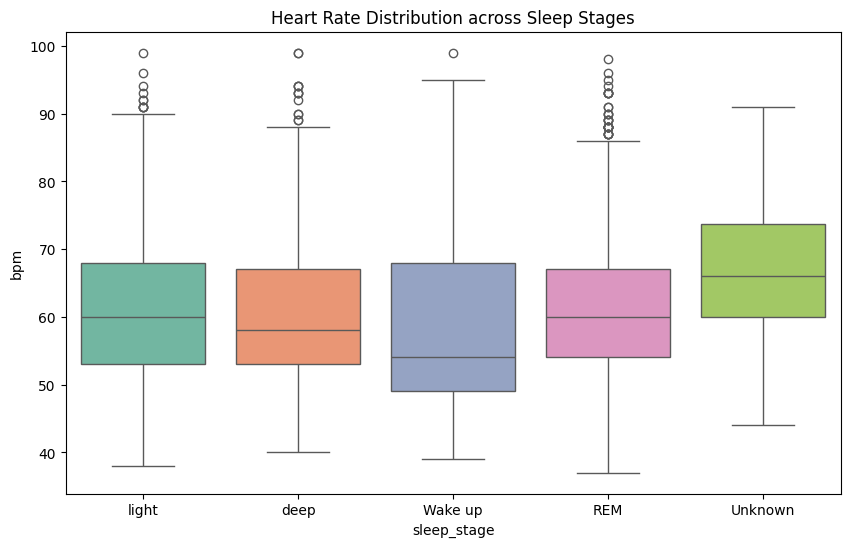

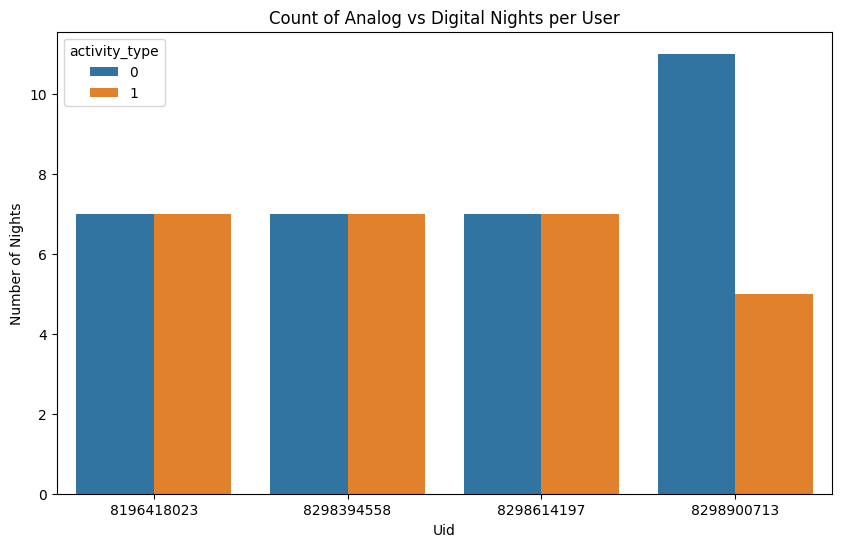

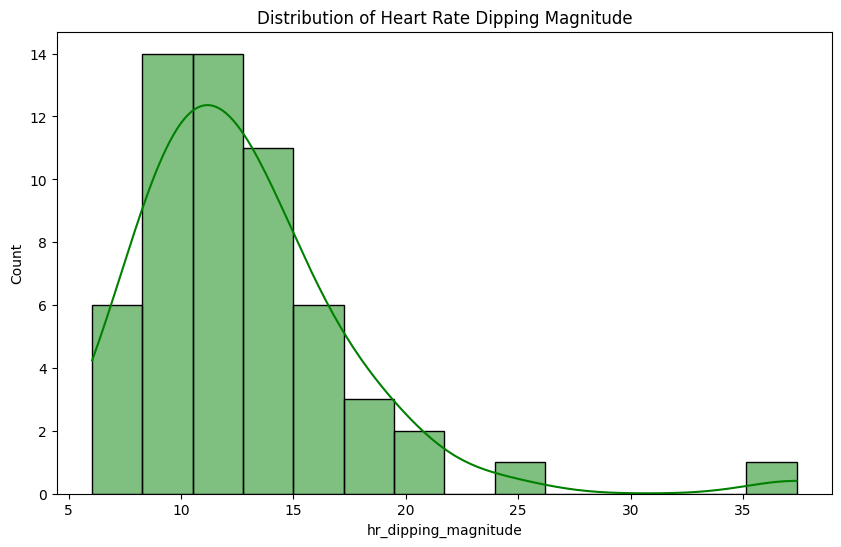

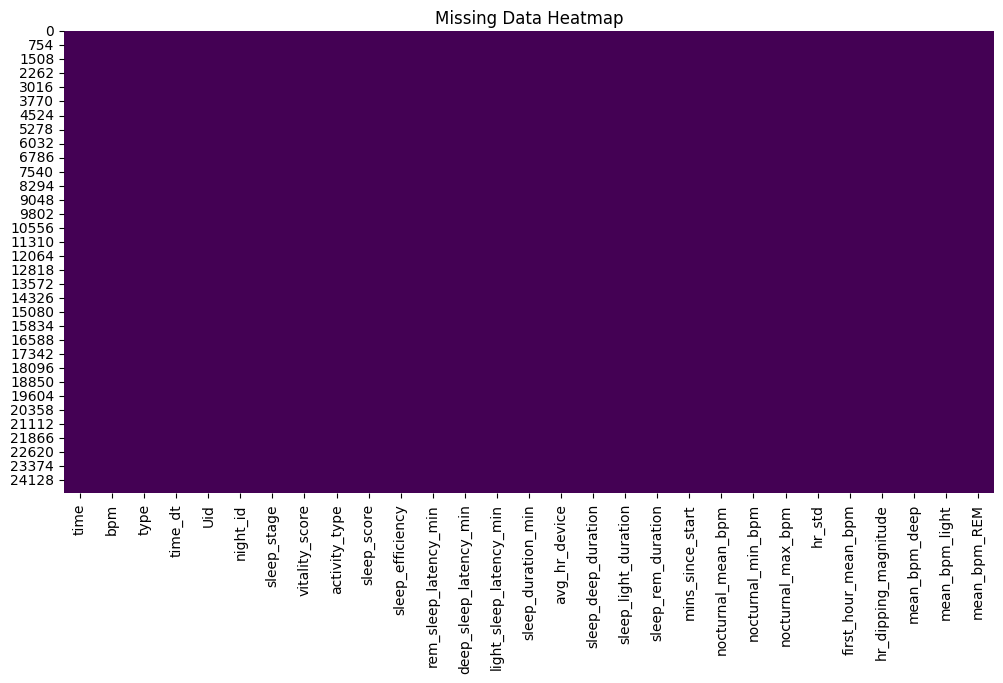

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load the fused dataset
df = pd.read_csv('Fused_Dataset.csv')

def perform_thorough_audit(df):
    print("=== 1. DATASET OVERVIEW ===")
    print(f"Total Rows: {len(df)}")
    print(f"Total Columns: {len(df.columns)}")
    print(f"Unique Users: {df['Uid'].nunique()}")
    print(f"Unique Nights: {df['night_id'].nunique()}")

    print("\n=== 1.1 ANALOG VS DIGITAL NIGHTS PER USER ===")
    # Check if the column exists (adjust 'activity_type' if your column name is different)
    activity_col = 'activity_type' 
    if activity_col in df.columns:
        # We group by Uid and Activity, then count unique night_ids
        night_counts = df.groupby(['Uid', activity_col])['night_id'].nunique().unstack(fill_value=0)
        print(night_counts)
        
        # Calculate totals
        total_analog = night_counts['Analog'].sum() if 'Analog' in night_counts.columns else 0
        total_digital = night_counts['Digital'].sum() if 'Digital' in night_counts.columns else 0
        print(f"\nGlobal Totals -> Analog: {total_analog}, Digital: {total_digital}")
    else:
        print(f"Warning: '{activity_col}' column not found to count Analog/Digital nights.")

    print("\n=== 2. MISSING DATA (EMPTY COLS/ROWS) ===")
    nulls = df.isnull().sum()
    null_pct = (nulls / len(df)) * 100
    missing_report = pd.DataFrame({'Null Count': nulls, 'Percentage': null_pct})
    print(missing_report[missing_report['Null Count'] > 0])
    
    print("\n=== 3. DUPLICATE CHECK ===")
    duplicates = df.duplicated().sum()
    print(f"Exact Duplicate Rows Found: {duplicates}")
    
    print("\n=== 4. PHYSIOLOGICAL SANITY CHECKS ===")
    outlier_hr = df[(df['bpm'] < 35) | (df['bpm'] > 180)]
    print(f"Physiologically implausible HR records (<35 or >180 bpm): {len(outlier_hr)}")
    
    if 'nocturnal_min_bpm' in df.columns:
        logic_errors = df[df['nocturnal_min_bpm'] > df['nocturnal_mean_bpm']]
        print(f"Logical Errors (Min HR > Mean HR): {len(logic_errors)}")

    print("\n=== 5. VARIABLE RANGES (STATISTICAL SUMMARY) ===")
    target_cols = [
        'bpm', 'nocturnal_mean_bpm', 'hr_std', 'hr_dipping_magnitude', 
        'first_hour_mean_bpm', 'sleep_score', 'sleep_efficiency'
    ]
    available_cols = [c for c in target_cols if c in df.columns]
    print(df[available_cols].describe().T)

    print("\n=== 6. GENERATING AUDIT VISUALIZATIONS ===")
    
    # Plot 1: Heart Rate Distribution by Sleep Stage
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='sleep_stage', y='bpm', palette='Set2')
    plt.title('Heart Rate Distribution across Sleep Stages')
    plt.savefig('audit_hr_by_stage.png')
    
    # Plot 2: Analog vs Digital Count
    if activity_col in df.columns:
        plt.figure(figsize=(10, 6))
        # Unique nights per user/activity
        plot_df = df.groupby(['Uid', activity_col])['night_id'].nunique().reset_index()
        sns.barplot(data=plot_df, x='Uid', y='night_id', hue=activity_col)
        plt.title('Count of Analog vs Digital Nights per User')
        plt.ylabel('Number of Nights')
        plt.savefig('audit_activity_counts.png')

    # Plot 3: HR Dipping Visualization
    if 'hr_dipping_magnitude' in df.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(df.groupby(['Uid', 'night_id'])['hr_dipping_magnitude'].mean(), kde=True, color='green')
        plt.title('Distribution of Heart Rate Dipping Magnitude')
        plt.savefig('audit_dipping_distribution.png')

    # Plot 3: Missing Values Heatmap
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Data Heatmap')
    plt.savefig('audit_missing_map.png')

    print("Audit Complete. Visualizations saved as 'audit_*.png'.")

# Execute the audit
perform_thorough_audit(df)

# Data Summarization

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, shapiro

# Load the big fused dataset
df_fused = pd.read_csv('Fused_Dataset.csv')

# The 16 columns we decided to keep
keep_columns = [
    'Uid', 'night_id', 'activity_type', 
    'deep_sleep_latency_min', 'rem_sleep_latency_min', 'light_sleep_latency_min',
    'sleep_efficiency', 'sleep_deep_duration', 'sleep_rem_duration', 'sleep_score',
    'vitality_score', 'hr_dipping_magnitude', 'nocturnal_mean_bpm', 
    'mean_bpm_deep', 'mean_bpm_light', 'mean_bpm_REM'
]

# Reduce to one row per night (taking .first() because these values are constant per night)
df_analysis = df_fused[keep_columns].groupby(['Uid', 'night_id']).first().reset_index()

# Save for your team members
df_analysis.to_csv('Nightly_Analysis_Summary.csv', index=False)

# Distribution + Statistical Model 

## Why Mann-Whitney U (not Wilcoxon Signed-Rank)
A Wilcoxon Signed-Rank test requires perfectly matched pairs per person.
One participant has zero analog nights, making true pairing impossible across the full sample.
The Mann-Whitney U test is the non-parametric equivalent for two independent groups —
same assumption-free logic, correct for this data shape.
We use it for all variables to stay consistent; if both groups pass Shapiro-Wilk the
code notes it, but we still use Mann-Whitney U to avoid mixing test types.

Total nights  : 58
Digital nights: 32
Analog  nights: 26
Unique users  : 4

STEP 1 - NORMALITY CHECKS (Shapiro-Wilk)

Deep Sleep Latency (min) (Primary Outcome)
  Digital : W=0.595, p=0.000  (NOT normal)
  Analog  : W=0.642, p=0.000  (NOT normal)
  -> Use Mann-Whitney U

Deep Sleep Duration (min) (Secondary Outcome)
  Digital : W=0.970, p=0.496  (normal)
  Analog  : W=0.952, p=0.254  (normal)
  BOTH NORMAL -> could use T-test, using Mann-Whitney U for consistency

Vitality Score (1-10) (Subjective Outcome)
  Digital : W=0.899, p=0.006  (NOT normal)
  Analog  : W=0.883, p=0.007  (NOT normal)
  -> Use Mann-Whitney U

Nocturnal Mean HR (BPM) (Physiological)
  Digital : W=0.972, p=0.559  (normal)
  Analog  : W=0.891, p=0.010  (NOT normal)
  -> Use Mann-Whitney U

HR Dipping Magnitude (BPM) (Physiological)
  Digital : W=0.898, p=0.006  (NOT normal)
  Analog  : W=0.733, p=0.000  (NOT normal)
  -> Use Mann-Whitney U


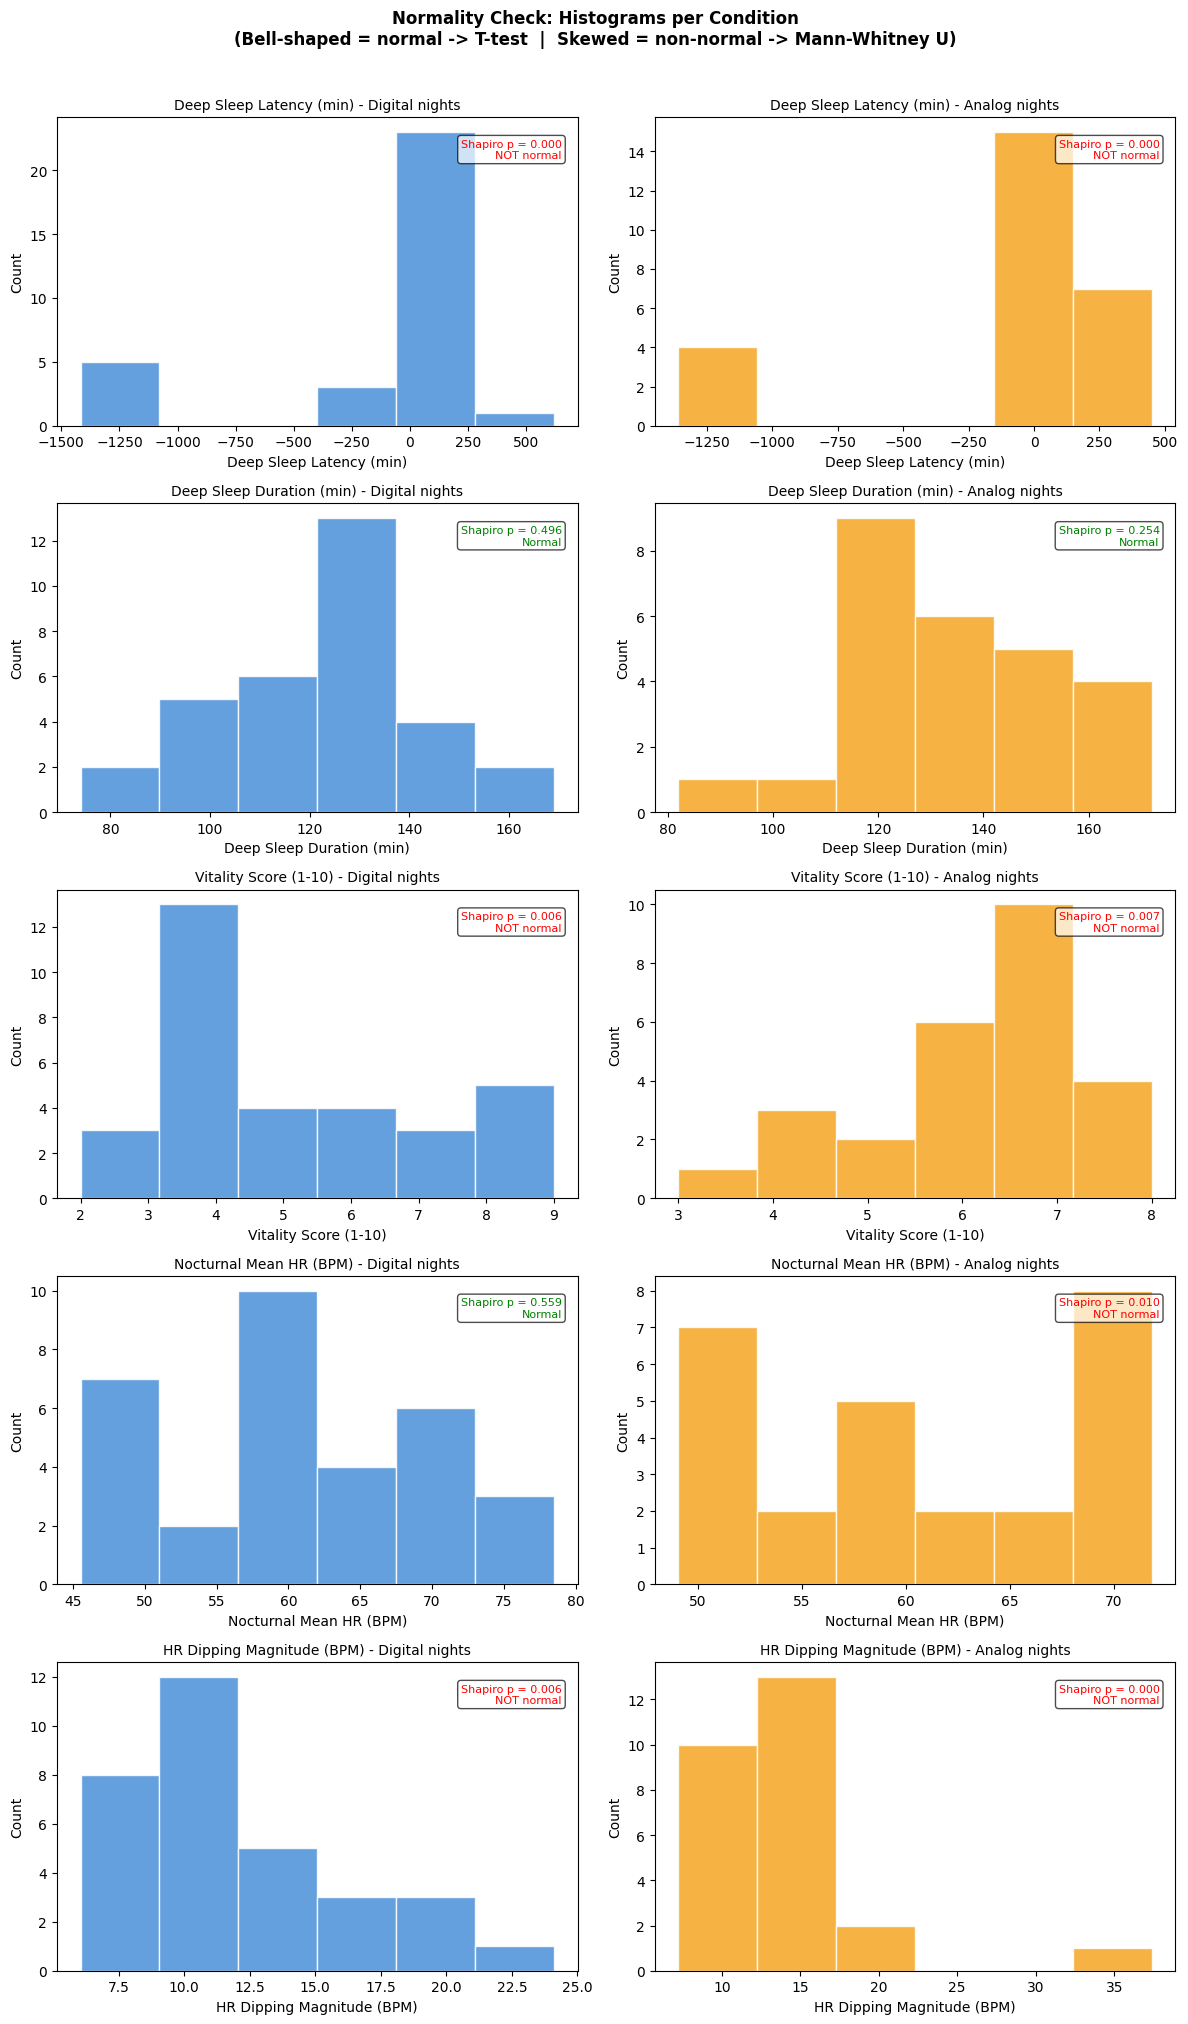


Saved: hist_normality_checks.png

STEP 2 - MANN-WHITNEY U TESTS
(Non-parametric, no normality assumption required)

Deep Sleep Latency (min)  [Primary Outcome]
  Digital median : 14.00
  Analog  median : 76.99
  U = 203.0,  p = 0.0009  ->  SIGNIFICANT
  Effect size r = 0.512  (large)

Deep Sleep Duration (min)  [Secondary Outcome]
  Digital median : 125.00
  Analog  median : 129.00
  U = 311.5,  p = 0.1037  ->  not significant
  Effect size r = 0.251  (small)

Vitality Score (1-10)  [Subjective Outcome]
  Digital median : 4.50
  Analog  median : 7.00
  U = 262.5,  p = 0.0146  ->  SIGNIFICANT
  Effect size r = 0.369  (medium)

Nocturnal Mean HR (BPM)  [Physiological]
  Digital median : 59.73
  Analog  median : 57.57
  U = 412.0,  p = 0.9564  ->  not significant
  Effect size r = 0.010  (small)

HR Dipping Magnitude (BPM)  [Physiological]
  Digital median : 10.70
  Analog  median : 13.54
  U = 293.5,  p = 0.0565  ->  not significant
  Effect size r = 0.294  (small)


-- Results Summary 

In [4]:
#Task 3: Imports
from scipy.stats import shapiro, mannwhitneyu
import numpy as np

# df_analysis is already in memory from the Data Summarization cell above.
# df_analysis = pd.read_csv('Nightly_Analysis_Summary.csv')

df_analysis['Condition'] = df_analysis['activity_type'].map({0: 'Digital', 1: 'Analog'})

digital = df_analysis[df_analysis['activity_type'] == 0]
analog  = df_analysis[df_analysis['activity_type'] == 1]

print(f"Total nights  : {len(df_analysis)}")
print(f"Digital nights: {len(digital)}")
print(f"Analog  nights: {len(analog)}")
print(f"Unique users  : {df_analysis['Uid'].nunique()}")
print()

# Variables analysed (column name, display label, role)
VARIABLES = [
    ('deep_sleep_latency_min',  'Deep Sleep Latency (min)',   'Primary Outcome'),
    ('sleep_deep_duration',     'Deep Sleep Duration (min)',  'Secondary Outcome'),
    ('vitality_score',          'Vitality Score (1-10)',      'Subjective Outcome'),
    ('nocturnal_mean_bpm',      'Nocturnal Mean HR (BPM)',    'Physiological'),
    ('hr_dipping_magnitude',    'HR Dipping Magnitude (BPM)', 'Physiological'),
]

#Step 1: Normality Check (Histograms + Shapiro-Wilk)
print("=" * 60)
print("STEP 1 - NORMALITY CHECKS (Shapiro-Wilk)")
print("=" * 60)

fig, axes = plt.subplots(len(VARIABLES), 2, figsize=(12, 4 * len(VARIABLES)))
fig.suptitle(
    'Normality Check: Histograms per Condition\n'
    '(Bell-shaped = normal -> T-test  |  Skewed = non-normal -> Mann-Whitney U)',
    fontsize=12, fontweight='bold', y=1.01
)

normality_results = {}

for row_idx, (col, label, tag) in enumerate(VARIABLES):
    d_vals = digital[col].dropna()
    a_vals = analog[col].dropna()

    # Shapiro-Wilk requires n >= 3
    sw_d = shapiro(d_vals) if len(d_vals) >= 3 else (np.nan, np.nan)
    sw_a = shapiro(a_vals) if len(a_vals) >= 3 else (np.nan, np.nan)

    normality_results[col] = {
        'digital_W': sw_d[0], 'digital_p': sw_d[1],
        'analog_W':  sw_a[0], 'analog_p':  sw_a[1],
        'both_normal': (sw_d[1] > 0.05) and (sw_a[1] > 0.05)
    }

    # Digital histogram
    ax0 = axes[row_idx, 0]
    ax0.hist(d_vals, bins=6, color='#4A90D9', edgecolor='white', alpha=0.85)
    ax0.set_title(f'{label} - Digital nights', fontsize=10)
    ax0.set_xlabel(label)
    ax0.set_ylabel('Count')
    norm_label_d = 'Normal' if sw_d[1] > 0.05 else 'NOT normal'
    ax0.text(0.97, 0.93, f'Shapiro p = {sw_d[1]:.3f}\n{norm_label_d}',
             transform=ax0.transAxes, ha='right', va='top', fontsize=8,
             color='green' if sw_d[1] > 0.05 else 'red',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    # Analog histogram
    ax1 = axes[row_idx, 1]
    ax1.hist(a_vals, bins=6, color='#F5A623', edgecolor='white', alpha=0.85)
    ax1.set_title(f'{label} - Analog nights', fontsize=10)
    ax1.set_xlabel(label)
    ax1.set_ylabel('Count')
    norm_label_a = 'Normal' if sw_a[1] > 0.05 else 'NOT normal'
    ax1.text(0.97, 0.93, f'Shapiro p = {sw_a[1]:.3f}\n{norm_label_a}',
             transform=ax1.transAxes, ha='right', va='top', fontsize=8,
             color='green' if sw_a[1] > 0.05 else 'red',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    decision = 'BOTH NORMAL -> could use T-test, using Mann-Whitney U for consistency' \
               if normality_results[col]['both_normal'] else '-> Use Mann-Whitney U'
    print(f"\n{label} ({tag})")
    print(f"  Digital : W={sw_d[0]:.3f}, p={sw_d[1]:.3f}  {'(normal)' if sw_d[1]>0.05 else '(NOT normal)'}")
    print(f"  Analog  : W={sw_a[0]:.3f}, p={sw_a[1]:.3f}  {'(normal)' if sw_a[1]>0.05 else '(NOT normal)'}")
    print(f"  {decision}")

plt.tight_layout()
plt.savefig('hist_normality_checks.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: hist_normality_checks.png")

#Step 2: Mann-Whitney U Tests
print("\n" + "=" * 60)
print("STEP 2 - MANN-WHITNEY U TESTS")
print("(Non-parametric, no normality assumption required)")
print("=" * 60)
print()

alpha = 0.05
results_rows = []

for col, label, tag in VARIABLES:
    d_vals = digital[col].dropna()
    a_vals = analog[col].dropna()

    stat, p = mannwhitneyu(d_vals, a_vals, alternative='two-sided')

    # Rank-biserial correlation as effect size: r = 1 - (2U / n1*n2)
    n1, n2 = len(d_vals), len(a_vals)
    r = 1 - (2 * stat) / (n1 * n2)

    sig = 'SIGNIFICANT' if p < alpha else 'not significant'
    effect_label = 'small' if abs(r) < 0.3 else ('medium' if abs(r) < 0.5 else 'large')

    results_rows.append({
        'Variable': label,
        'Tag': tag,
        'Digital median': round(d_vals.median(), 2),
        'Analog median':  round(a_vals.median(), 2),
        'U statistic': stat,
        'p-value': round(p, 4),
        'Effect size r': round(r, 3),
        'Effect magnitude': effect_label,
        'Significant (a=0.05)': p < alpha
    })

    print(f"{label}  [{tag}]")
    print(f"  Digital median : {d_vals.median():.2f}")
    print(f"  Analog  median : {a_vals.median():.2f}")
    print(f"  U = {stat:.1f},  p = {p:.4f}  ->  {sig}")
    print(f"  Effect size r = {r:.3f}  ({effect_label})")
    print()

# Store results in a dataframe for re-use in visualizations
df_results = pd.DataFrame(results_rows)
print("\n-- Results Summary Table --")
print(df_results[['Variable', 'Digital median', 'Analog median',
                   'p-value', 'Effect size r', 'Significant (a=0.05)']].to_string(index=False))

df_results.to_csv('statistical_results.csv', index=False)
print("\nSaved: statistical_results.csv")

# Task 3b: Spearman Correlation for H3
from scipy.stats import spearmanr

print("=" * 60)
print("STEP 3 - SPEARMAN CORRELATIONS (H3: Vitality vs. Physiology)")
print("=" * 60)

# We want to see if Latency or Dipping correlates with Vitality
corr_pairs = [
    ('deep_sleep_latency_min', 'vitality_score'),
    ('hr_dipping_magnitude', 'vitality_score')
]

for col1, col2 in corr_pairs:
    # Use the whole dataset to see the general trend
    valid_data = df_analysis[[col1, col2]].dropna()
    rho, p_val = spearmanr(valid_data[col1], valid_data[col2])
    
    sig = "Significant" if p_val < 0.05 else "Not significant"
    direction = "positive" if rho > 0 else "negative"
    
    print(f"Correlation between {col1} and {col2}:")
    print(f"  Spearman's Rho: {rho:.3f}")
    print(f"  p-value: {p_val:.4f} ({sig})")
    print(f"  Interpretation: A {direction} relationship exists.\n")


# Visualizations (Clement & Utsav — Task 4)

C:\Users\utsav\AppData\Local\Temp\ipykernel_29744\2086263977.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analysis, x='Condition', y=col,
C:\Users\utsav\AppData\Local\Temp\ipykernel_29744\2086263977.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_analysis, x='Condition', y=col,
C:\Users\utsav\AppData\Local\Temp\ipykernel_29744\2086263977.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analysis, x='Condition', y=col,
C:\Users\utsav\AppData\Local\Temp\ipykernel_29744\2086263977.py:13: FutureWarning: 

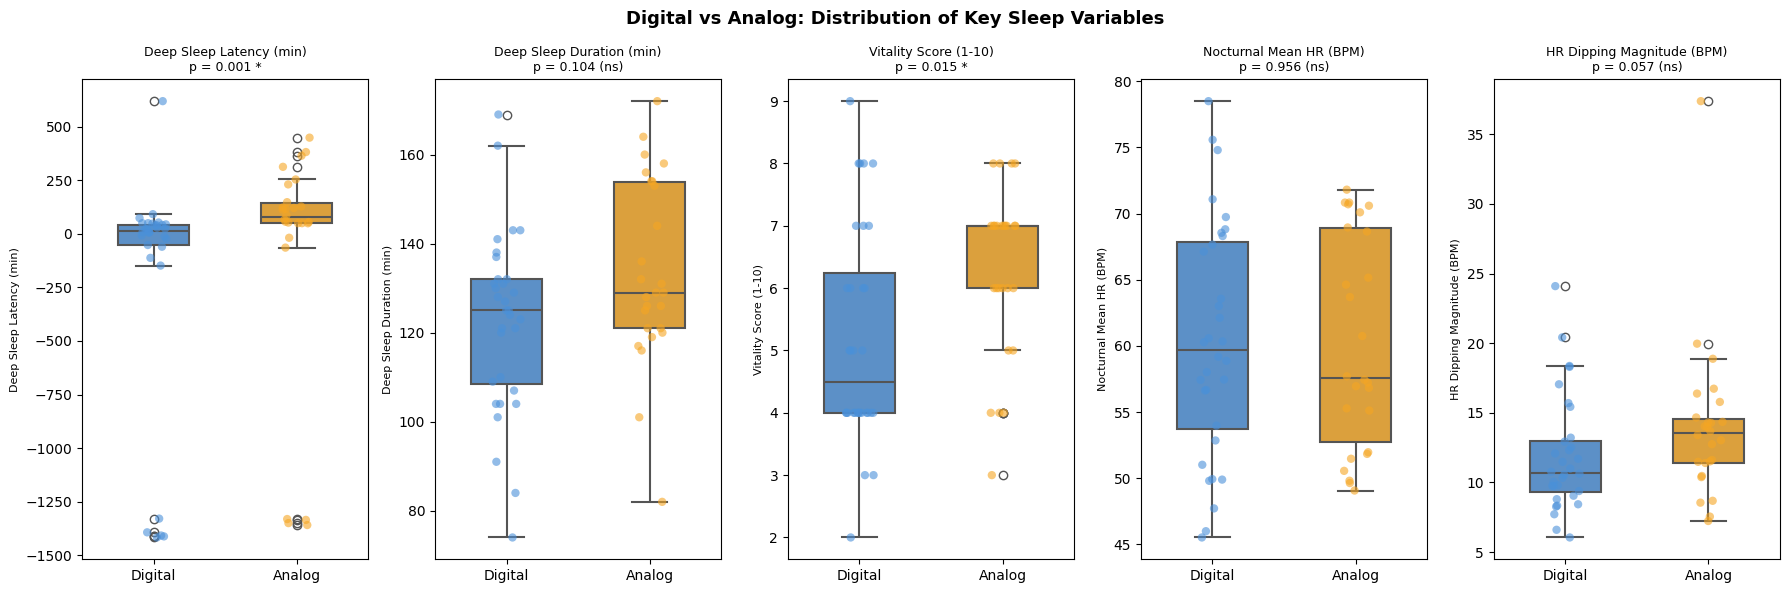

Saved: viz_boxplots.png


C:\Users\utsav\AppData\Local\Temp\ipykernel_29744\2086263977.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_analysis, x='Condition', y='deep_sleep_latency_min',
C:\Users\utsav\AppData\Local\Temp\ipykernel_29744\2086263977.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_analysis, x='Condition', y='deep_sleep_latency_min',


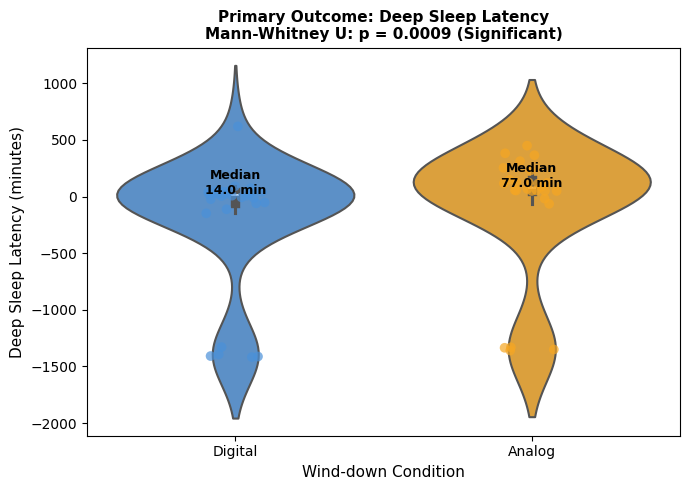

Saved: viz_primary_outcome.png


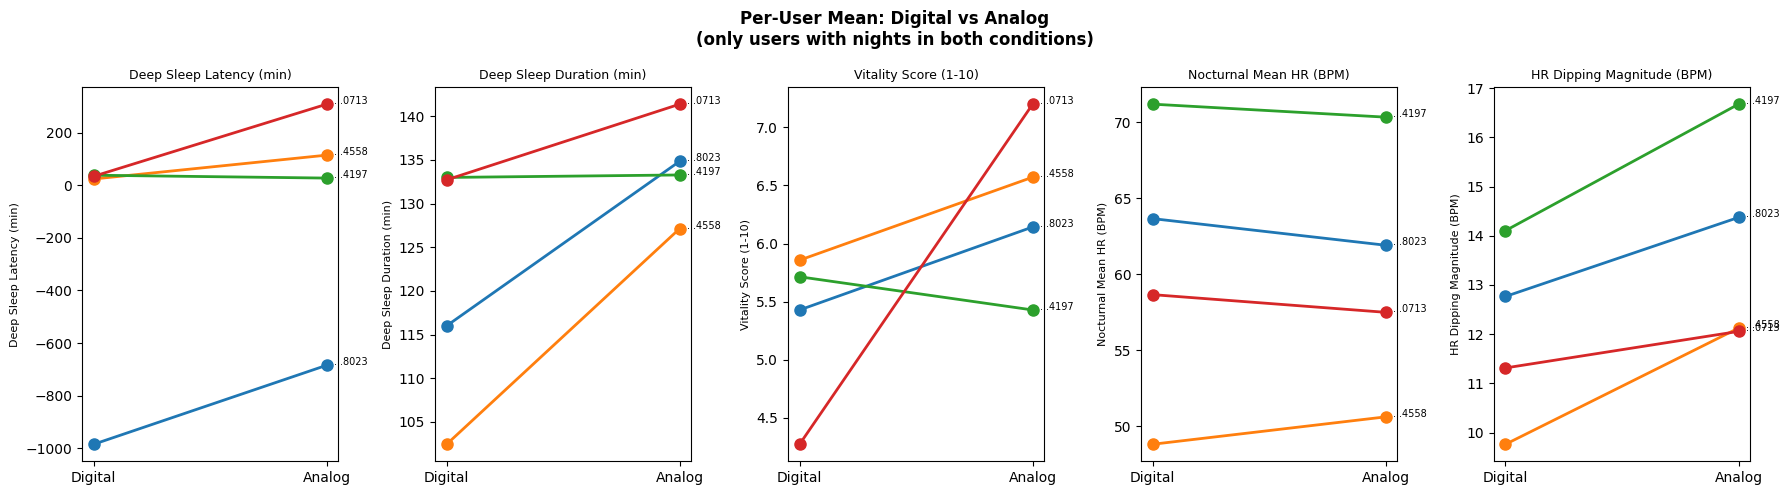

Saved: viz_per_user.png


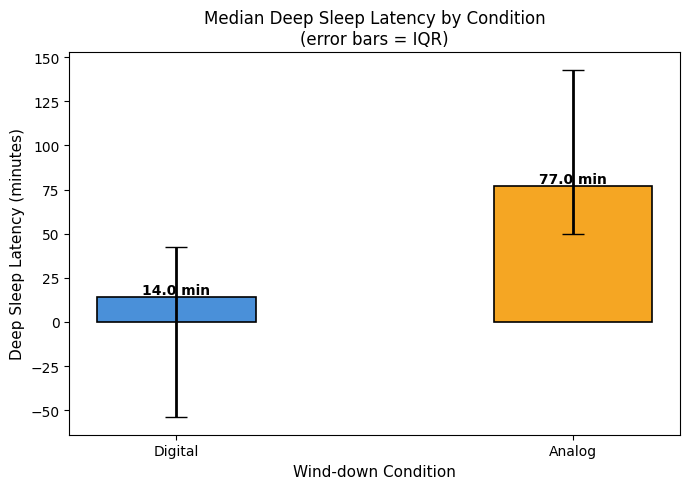

Saved: viz_summary_bar.png

All Task 4 plots saved:
  viz_boxplots.png        - all variables side by side
  viz_primary_outcome.png - violin for deep sleep latency
  viz_per_user.png        - per-user slope chart
  viz_summary_bar.png     - median bar chart with IQR


In [5]:
PALETTE = {'Digital': '#4A90D9', 'Analog': '#F5A623'}

#plot 1 Boxplots for all key variables 
fig, axes = plt.subplots(1, len(VARIABLES), figsize=(18, 6))
fig.suptitle('Digital vs Analog: Distribution of Key Sleep Variables',
             fontsize=13, fontweight='bold')

for ax, (col, label, tag) in zip(axes, VARIABLES):
    #use x= only (no hue) compatible with all seaborn versions
    sns.boxplot(data=df_analysis, x='Condition', y=col,
                palette=PALETTE, ax=ax,
                order=['Digital', 'Analog'], width=0.5, linewidth=1.5)
    sns.stripplot(data=df_analysis, x='Condition', y=col,
                  palette=PALETTE, ax=ax,
                  order=['Digital', 'Analog'], size=6, alpha=0.6, jitter=True)

    p_row = df_results.loc[df_results['Variable'] == label, 'p-value']
    if not p_row.empty:
        p_val = p_row.values[0]
        sig_text = f'p = {p_val:.3f} {"*" if p_val < 0.05 else "(ns)"}'
        ax.set_title(f'{label}\n{sig_text}', fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel(label, fontsize=8)

plt.tight_layout()
plt.savefig('viz_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_boxplots.png")

#Plot 2: Violin plot for the PRIMARY outcome (deep sleep latency)
fig, ax = plt.subplots(figsize=(7, 5))

sns.violinplot(data=df_analysis, x='Condition', y='deep_sleep_latency_min',
               palette=PALETTE, order=['Digital', 'Analog'],
               inner='box', ax=ax, linewidth=1.5)
sns.stripplot(data=df_analysis, x='Condition', y='deep_sleep_latency_min',
              palette=PALETTE, order=['Digital', 'Analog'],
              size=7, alpha=0.7, jitter=True, ax=ax)

p_primary = df_results.loc[
    df_results['Variable'] == 'Deep Sleep Latency (min)', 'p-value'
].values[0]
sig_str = '(Significant)' if p_primary < 0.05 else '(Not significant)'
ax.set_title(
    f'Primary Outcome: Deep Sleep Latency\n'
    f'Mann-Whitney U: p = {p_primary:.4f} {sig_str}',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Wind-down Condition', fontsize=11)
ax.set_ylabel('Deep Sleep Latency (minutes)', fontsize=11)

for i, cond in enumerate(['Digital', 'Analog']):
    med = df_analysis[df_analysis['Condition'] == cond]['deep_sleep_latency_min'].median()
    ax.text(i, med + 5, f'Median\n{med:.1f} min',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_primary_outcome.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_primary_outcome.png")

# Plot 3: Per-user slope chart 
users_with_both = (
    df_analysis.groupby('Uid')['activity_type'].nunique()
    .pipe(lambda s: s[s == 2].index.tolist())
)

fig, axes = plt.subplots(1, len(VARIABLES), figsize=(18, 5))
fig.suptitle('Per-User Mean: Digital vs Analog\n(only users with nights in both conditions)',
             fontsize=12, fontweight='bold')

for ax, (col, label, tag) in zip(axes, VARIABLES):
    user_means = (
        df_analysis[df_analysis['Uid'].isin(users_with_both)]
        .groupby(['Uid', 'Condition'])[col].mean()
        .unstack('Condition')
    )
    for uid, row in user_means.iterrows():
        ax.plot(['Digital', 'Analog'], [row['Digital'], row['Analog']],
                'o-', linewidth=2, markersize=8)
        ax.annotate(f'...{str(uid)[-4:]}',
                    xy=('Analog', row['Analog']),
                    xytext=(5, 0), textcoords='offset points', fontsize=7)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel(label, fontsize=8)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('viz_per_user.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_per_user.png")

# Plot 4: Median bar chart with IQR error bars (primary outcome) 
fig, ax = plt.subplots(figsize=(7, 5))

col = 'deep_sleep_latency_min'
summary = df_analysis.groupby('Condition')[col].agg(
    median='median',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
).reindex(['Digital', 'Analog'])

bars = ax.bar(
    summary.index,
    summary['median'],
    yerr=[summary['median'] - summary['q25'],
          summary['q75'] - summary['median']],
    capsize=8,
    color=[PALETTE[c] for c in summary.index],
    edgecolor='black', linewidth=1.2, width=0.4,
    error_kw={'linewidth': 2}
)
ax.set_title('Median Deep Sleep Latency by Condition\n(error bars = IQR)', fontsize=12)
ax.set_ylabel('Deep Sleep Latency (minutes)', fontsize=11)
ax.set_xlabel('Wind-down Condition', fontsize=11)

for bar, val in zip(bars, summary['median']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f'{val:.1f} min', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_summary_bar.png")

print("\nAll Task 4 plots saved:")
print("  viz_boxplots.png        - all variables side by side")
print("  viz_primary_outcome.png - violin for deep sleep latency")
print("  viz_per_user.png        - per-user slope chart")
print("  viz_summary_bar.png     - median bar chart with IQR")


In [ ]:

import statsmodels.api as sm
import statsmodels.formula.api as smf

print("=" * 60)
print("STEP 4 - ADVANCED ANALYSIS: GLM (Controlling for Sleep Duration)")
print("=" * 60)

# We want to see if 'Condition' (Digital/Analog) predicts 'Vitality' 
# while removing the influence of 'Total Sleep Duration'.
# We use a GLM because Vitality is not normally distributed.

# Prepare the formula: Vitality ~ Condition + Total_Sleep_Duration
model = smf.glm(formula="vitality_score ~ Condition + sleep_deep_duration", 
                data=df_analysis, 
                family=sm.families.Gaussian()) # Or Gamma if highly skewed

model_results = model.fit()

print(model_results.summary())

'pip' is not recognized as an internal or external command,
operable program or batch file.


ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Assumes df_analysis is already in memory from your Data Summarization cell ──
# If not, uncomment the line below:
# df_analysis = pd.read_csv('Nightly_Analysis_Summary.csv')

PALETTE = {'Digital': '#4A90D9', 'Analog': '#F5A623'}

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 5: Spearman Correlation Scatterplots (H3)
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#F8F9FA')

scatter_cfg = [
    ('deep_sleep_latency_min', 'vitality_score',
     'Deep Sleep Latency (min)', 'Vitality Score (1–10)',
     'H3: Latency → Vitality',
     r'$\rho = 0.307$,  $p = 0.019$ *'),
    ('hr_dipping_magnitude', 'vitality_score',
     'HR Dipping Magnitude (BPM)', 'Vitality Score (1–10)',
     'H3: HR Dipping → Vitality',
     r'$\rho = 0.188$,  $p = 0.157$ (ns)'),
]

for ax, (xcol, ycol, xlabel, ylabel, title, rho_label) in zip(axes, scatter_cfg):
    ax.set_facecolor('white')

    # One dot per night, colored by condition
    for cond, grp in df_analysis.groupby('Condition'):
        ax.scatter(grp[xcol], grp[ycol],
                   color=PALETTE[cond], alpha=0.75, s=65,
                   edgecolors='white', linewidth=0.6,
                   label=cond, zorder=3)

    # Overall trend line across all nights
    valid = df_analysis[[xcol, ycol]].dropna()
    m, b = np.polyfit(valid[xcol], valid[ycol], 1)
    x_line = np.linspace(valid[xcol].min(), valid[xcol].max(), 200)
    ax.plot(x_line, m * x_line + b, color='#333333', linewidth=1.8,
            linestyle='--', zorder=4, label='Trend (all nights)')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

    # Rho annotation box
    ax.text(0.97, 0.05, rho_label,
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=10, fontstyle='italic',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFFBEA',
                      edgecolor='#CCAA00', alpha=0.9))

    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

axes[0].legend(frameon=False, fontsize=9)

fig.suptitle('Spearman Correlations: Physiology → Next-Morning Vitality',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_spearman_correlations.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: viz_spearman_correlations.png")


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 6: Nocturnal HR Trajectory (H1)
# Uses real minute-level data from Fused_Dataset.csv
# ═══════════════════════════════════════════════════════════════════════════════

# Load the full fused dataset (needs minute-level bpm + mins_since_start)
df_fused = pd.read_csv('Fused_Dataset.csv')

# Map condition label
df_fused['Condition'] = df_fused['activity_type'].map({0: 'Digital', 1: 'Analog'})

# Average BPM per minute-since-start, per condition
trajectory = (
    df_fused.groupby(['Condition', 'mins_since_start'])['bpm']
    .mean()
    .reset_index()
)

def smooth(series, window=12):
    return series.rolling(window, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('white')

for cond in ['Digital', 'Analog']:
    grp = trajectory[trajectory['Condition'] == cond].sort_values('mins_since_start')
    mins = grp['mins_since_start'].values
    bpm  = smooth(grp['bpm']).values

    # SD band across nights for that condition
    sd_data = (
        df_fused[df_fused['Condition'] == cond]
        .groupby('mins_since_start')['bpm'].std()
        .reset_index()
        .sort_values('mins_since_start')
    )
    sd_vals = smooth(sd_data['bpm']).values
    sd_mins = sd_data['mins_since_start'].values

    ax.fill_between(sd_mins, bpm[:len(sd_mins)] - sd_vals,
                              bpm[:len(sd_mins)] + sd_vals,
                    color=PALETTE[cond], alpha=0.15)
    ax.plot(mins, bpm, color=PALETTE[cond], linewidth=2.5, label=cond)

# Dipping magnitude annotations — drawn at the nocturnal minimum of each curve
for cond in ['Digital', 'Analog']:
    grp = trajectory[trajectory['Condition'] == cond].sort_values('mins_since_start')
    bpm_smooth = smooth(grp['bpm']).values
    mins = grp['mins_since_start'].values

    first_hr  = bpm_smooth[:60].mean()
    min_idx   = np.argmin(bpm_smooth)
    min_hr    = bpm_smooth[min_idx]
    dip_label = '≈10.7 BPM' if cond == 'Digital' else '≈13.5 BPM'
    x_pos     = mins[min_idx]
    offset    = +18 if cond == 'Digital' else -55

    ax.annotate('', xy=(x_pos, min_hr), xytext=(x_pos, first_hr),
                arrowprops=dict(arrowstyle='<->', color=PALETTE[cond], lw=1.5))
    ax.text(x_pos + offset, (min_hr + first_hr) / 2,
            f'{cond} dip\n{dip_label}',
            color=PALETTE[cond], fontsize=8.5, va='center')

# Sleep-stage background bands (approximate, cosmetic only)
stage_bands = [
    (0,   90,  '#CCE5FF', 'Light / REM'),
    (90,  210, '#6699CC', 'Deep'),
    (210, 330, '#CCE5FF', 'Light / REM'),
    (330, 420, '#4A6FA5', 'Deep'),
    (420, 480, '#CCE5FF', 'REM'),
]
for xstart, xend, color, slabel in stage_bands:
    ax.axvspan(xstart, xend, alpha=0.07, color=color, zorder=0)
    ax.text((xstart + xend) / 2, ax.get_ylim()[0] + 0.5, slabel,
            ha='center', va='bottom', fontsize=7, color='#666666')

ax.set_xlabel('Time since sleep onset', fontsize=11)
ax.set_ylabel('Heart Rate (BPM)', fontsize=11)
ax.set_title('Nocturnal HR Trajectory: Digital vs Analog Wind-down\n'
             '(Group mean ± SD, 1-min resolution)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 480)
ax.set_xticks(np.arange(0, 481, 60))
ax.set_xticklabels([f'{int(t // 60)}h' for t in np.arange(0, 481, 60)])
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.legend(frameon=False, fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('viz_hr_trajectory.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: viz_hr_trajectory.png")